<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Diya's-New-Branch/Feature_Significance_Analysis_LGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

import joblib   # or import pickle
model = joblib.load("/content/drive/MyDrive/lightgbm_noencoding_engfeat_prepv2_tuned.pkl")   # change to your actual filename

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import lightgbm as lgb
import pandas as pd
import numpy as np

# 1. Get the underlying Booster (works whether you used LGBMRegressor/LGBMClassifier or Booster)
# Check if the 'model' variable is a dict and extract the actual LGBM model if it is.
if isinstance(model, dict) and 'model' in model:
    lgbm_model = model['model']
else:
    lgbm_model = model

if isinstance(lgbm_model, lgb.Booster):
    booster = lgbm_model
else:
    booster = lgbm_model.booster_

# 2. Get feature names + importance by gain (usually more useful than split count)
feature_names = booster.feature_name()
importances_gain = booster.feature_importance(importance_type="gain")

# 3. Put it in a DataFrame and sort
fi_df = pd.DataFrame({
    "feature": feature_names,
    "gain_importance": importances_gain
}).sort_values("gain_importance", ascending=False)

fi_df.head(30)  # show top 30

,feature,gain_importance
11,apr_drg_code,3.470001e+08
22,emergency_x_severity,2.178003e+08
10,ccsr_px_code,1.268759e+08
2,facility_id,1.116774e+08
9,ccsr_dx_code,8.556201e+07
13,apr_severity_code,5.463001e+07
12,apr_mdc_code,4.687882e+07
20,high_mortality_risk,4.362099e+07
14,apr_mortality_risk,1.793293e+07
4,zip_code,1.732853e+07


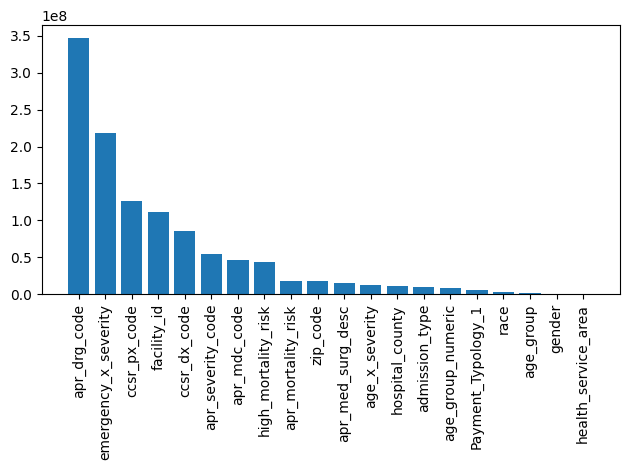

In [35]:
import matplotlib.pyplot as plt

top_k = 20
top = fi_df.head(top_k)

plt.bar(range(len(top)), top["gain_importance"])
plt.xticks(range(len(top)), top["feature"], rotation=90)
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

# Use the already computed 'grouped' DataFrame
fac_los = grouped.sort_values("length_of_stay", ascending=False)

print("🔴 Facility with the HIGHEST mean LOS")
display(fac_los.head(1))

print("🟢 Facility with the LOWEST mean LOS")
display(fac_los.tail(1))

🔴 Facility with the HIGHEST mean LOS


,facility_id,length_of_stay
129,1138,50.559775


🟢 Facility with the LOWEST mean LOS


,facility_id,length_of_stay
166,1460,1.711111


In [38]:
import pandas as pd

df = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
# Replace 'facility_id' and 'length_of_stay' with your actual column names

grouped = df.groupby("facility_id")["length_of_stay"].mean().reset_index()
grouped = grouped.sort_values("length_of_stay", ascending=False)

print("🔴 Facility with the HIGHEST mean LOS:")
display(grouped.head(1))

print("🟢 Facility with the LOWEST mean LOS:")
display(grouped.tail(1))


🔴 Facility with the HIGHEST mean LOS:


,facility_id,length_of_stay
129,1138,50.559775


🟢 Facility with the LOWEST mean LOS:


,facility_id,length_of_stay
166,1460,1.711111


In [39]:

#Investigate why those facilities have high LOS
#check which diagnoses, severities, or admission types dominate those facilities

high_fac = grouped.iloc[0]["facility_id"]
low_fac  = grouped.iloc[-1]["facility_id"]

print("Common diagnoses for HIGHEST LOS facility:")
display(df[df["facility_id"] == high_fac]["ccsr_dx_code"].value_counts().head(10))

print("\nCommon diagnoses for LOWEST LOS facility:")
display(df[df["facility_id"] == low_fac]["ccsr_dx_code"].value_counts().head(10))


Common diagnoses for HIGHEST LOS facility:


,count
ccsr_dx_code,
SYM016,166
FAC010,93
PNL006,65
RSP012,53
SYM007,49
INJ045,47
FAC008,31
CIR022,24
NVS002,24



Common diagnoses for LOWEST LOS facility:


,count
ccsr_dx_code,
MBD013,38
GEN026,4
RSP001,1
DIG024,1
RSP007,1


In [40]:
from google.colab import drive
drive.mount('/content/drive')

ccsr_map = pd.read_excel("/content/drive/MyDrive/sparcs_mappings.xlsx", sheet_name='Ccsr Diagnosis Code')
# adjust column names here:
# e.g. columns might be: 'ccsr_dx_code', 'description'

code_to_desc = ccsr_map.set_index("Code")["Description"].to_dict()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# Removed temporary definition of high_name and low_name that caused KeyError

# High-LOS facility
dx_high = (
    df[df["facility_id"] == high_fac]["ccsr_dx_code"]
      .value_counts()
      .rename_axis("ccsr_dx_code")
      .reset_index(name="count")
)

dx_high["description"] = dx_high["ccsr_dx_code"].map(ccsr_dx_code_to_desc)

print("Common diagnoses for HIGHEST LOS facility:", high_fac)
display(dx_high.head(10))


# Low-LOS facility
dx_low = (
    df[df["facility_id"] == low_fac]["ccsr_dx_code"]
      .value_counts()
      .rename_axis("ccsr_dx_code")
      .reset_index(name="count")
)

dx_low["description"] = dx_low["ccsr_dx_code"].map(ccsr_dx_code_to_desc)

print("Common diagnoses for LOWEST LOS facility:", low_fac)
display(dx_low.head(10))

Common diagnoses for HIGHEST LOS facility: 1138.0


,ccsr_dx_code,count,description
0,SYM016,166,OTHER GENERAL SIGNS AND SYMPTOMS
1,FAC010,93,OTHER AFTERCARE ENCOUNTER
2,PNL006,65,RESPIRATORY PERINATAL CONDITION
3,RSP012,53,RESPIRATORY FAILURE; INSUFFICIENCY; ARREST
4,SYM007,49,MALAISE AND FATIGUE
5,INJ045,47,"TRAUMATIC BRAIN INJURY (TBI); CONCUSSION, SUBS..."
6,FAC008,31,NEOPLASM-RELATED ENCOUNTERS
7,CIR022,24,SEQUELA OF HEMORRHAGIC CEREBROVASCULAR DISEASE
8,NVS002,24,ENCEPHALITIS
9,CIR025,22,SEQUELA OF CEREBRAL INFARCTION AND OTHER CEREB...


Common diagnoses for LOWEST LOS facility: 1460.0


,ccsr_dx_code,count,description
0,MBD013,38,MISCELLANEOUS MENTAL AND BEHAVIORAL DISORDERS/...
1,GEN026,4,POSTPROCEDURAL OR POSTOPERATIVE GENITOURINARY ...
2,RSP001,1,SINUSITIS
3,DIG024,1,POSTPROCEDURAL OR POSTOPERATIVE DIGESTIVE SYST...
4,RSP007,1,OTHER SPECIFIED AND UNSPECIFIED UPPER RESPIRAT...


In [44]:
apr_map = pd.read_excel("/content/drive/MyDrive/sparcs_mappings.xlsx", sheet_name='Apr Drg Code')
# adjust column names here:
# e.g. columns might be: 'ccsr_dx_code', 'description'

apr_code_to_desc = apr_map.set_index("Code")["Description"].to_dict()

In [45]:
# High-LOS facility
dx_high = (
    df[df["facility_id"] == high_fac]["apr_drg_code"]
      .value_counts()
      .rename_axis("apr_drg_code")
      .reset_index(name="count")
)

dx_high["description"] = dx_high["apr_drg_code"].map(apr_code_to_desc)

print("Common diagnoses for HIGHEST LOS facility:", high_fac)
display(dx_high.head(10))


# Low-LOS facility
dx_low = (
    df[df["facility_id"] == low_fac]["apr_drg_code"]
      .value_counts()
      .rename_axis("apr_drg_code")
      .reset_index(name="count")
)

dx_low["description"] = dx_low["apr_drg_code"].map(apr_code_to_desc)

print("Common diagnoses for LOWEST LOS facility:", low_fac)
display(dx_low.head(10))

Common diagnoses for HIGHEST LOS facility: 1138.0


,apr_drg_code,count,description
0,421,174,"MALNUTRITION, FAILURE TO THRIVE AND OTHER NUTR..."
1,860,157,REHABILITATION
2,862,83,OTHER AFTERCARE AND CONVALESCENCE
3,130,72,RESPIRATORY SYSTEM DIAGNOSIS WITH VENTILATOR S...
4,58,66,OTHER DISORDERS OF NERVOUS SYSTEM
5,132,33,BPD AND OTHER CHRONIC RESPIRATORY DISEASES ARI...
6,50,23,NON-BACTERIAL INFECTIONS OF NERVOUS SYSTEM EXC...
7,133,17,RESPIRATORY FAILURE
8,200,9,CARDIAC STRUCTURAL AND VALVULAR DISORDERS
9,40,8,SPINAL DISORDERS AND INJURIES


Common diagnoses for LOWEST LOS facility: 1460.0


,apr_drg_code,count,description
0,851,21,GENDER RELATED PROCEDURES
1,740,17,MENTAL ILLNESS DIAGNOSIS WITH O.R. PROCEDURE
2,445,2,OTHER BLADDER PROCEDURES
3,446,1,URETHRAL AND TRANSURETHRAL PROCEDURES
4,952,1,NON-EXTENSIVE O.R. PROCEDURE UNRELATED TO PRIN...
5,92,1,FACIAL BONE PROCEDURES EXCEPT MAJOR CRANIAL OR...
6,252,1,"MALFUNCTION, REACTION AND COMPLICATION OF GAST..."
7,951,1,MODERATELY EXTENSIVE O.R. PROCEDURE UNRELATED ...


In [53]:
# Top 10 emergency_x_severity combos by mean LOS in the highest-LOS facility
high_emerg_sev = (
    df[df["facility_id"] == high_fac]
      .groupby("emergency_x_severity")["length_of_stay"]
      .agg(mean_los="mean", n_admissions="size")
      .reset_index()
      .sort_values("mean_los", ascending=False)
      .head(10)
)

print("Top 10 emergency_x_severity combos in HIGHEST-LOS facility:")
display(high_emerg_sev)


Top 10 emergency_x_severity combos in HIGHEST-LOS facility:


,emergency_x_severity,mean_los,n_admissions
3,4,62.627907,86
2,3,57.768519,324
1,2,41.754310,232
0,1,31.275362,69


In [51]:
# Recreate the 'high_severity' and 'severity_numeric' columns as per original feature engineering

# Ensure 'apr_severity_code' is present before proceeding
if 'apr_severity_code' in df.columns:
    # Severity indicators (binary flags) - recreating high_severity
    df['high_severity'] = (df['apr_severity_code'].isin(['3', '4'])).astype(int)

    # Convert severity to numeric for interactions - recreating severity_numeric
    severity_numeric = pd.to_numeric(df['apr_severity_code'], errors='coerce').fillna(0)

    # Create the 'emergency_x_severity' interaction feature if it does not exist
    if 'emergency_x_severity' not in df.columns:
        df['emergency_x_severity'] = df['emergency_dept_indicator'].astype(int) * severity_numeric
        print("Recreated 'high_severity', 'severity_numeric', and 'emergency_x_severity' features.")
    else:
        print("'emergency_x_severity' feature already exists, ensuring dependencies are met.")
else:
    print("Error: 'apr_severity_code' column not found in DataFrame. Cannot recreate severity features.")

'emergency_x_severity' feature already exists, ensuring dependencies are met.


In [54]:
# Top 10 emergency_x_severity combos by mean LOS in the lowest-LOS facility
low_emerg_sev = (
    df[df["facility_id"] == low_fac]
      .groupby("emergency_x_severity")["length_of_stay"]
      .agg(mean_los="mean", n_admissions="size")
      .reset_index()
      .sort_values("mean_los", ascending=False)
      .head(10)
)

print("🟢 Top 10 emergency_x_severity combos in LOWEST-LOS facility:")
display(low_emerg_sev)


🟢 Top 10 emergency_x_severity combos in LOWEST-LOS facility:


,emergency_x_severity,mean_los,n_admissions
1,2,2.000000,2
0,1,1.697674,43
